# QickSim RFDC Output Waveform Demo

This notebook demonstrates an `AveragerProgram`-style AWG tuning program and plots the RFDC-facing digital output streams discovered from the HWH topology, without PYNQ hardware, RFDC hardware, Vivado, or bitstream download.

The output samples shown here are the packed/lane samples at the RFDC AXIS DAC inputs. They are not analog RFDC output waveforms.

In [1]:
from pathlib import Path
import sys

REPO = Path(r"C:\JeonghyunPark\Workspace\QSTL_QICK")
QICK_LIB = REPO / "qick" / "qick_lib"
if str(QICK_LIB) not in sys.path:
    sys.path.insert(0, str(QICK_LIB))

from qick import AveragerProgram
from qick.sim import QickSim

print("QICK lib:", QICK_LIB)

QICK lib: C:\JeonghyunPark\Workspace\QSTL_QICK\qick\qick_lib


c:\JeonghyunPark\Anaconda\envs\qick_test\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

All clock values are in MHz. `dac_clk` is the RFDC DAC sample rate, `fabric_clk` is the RFDC/generator fabric clock, and `tproc_clk` is the tProcessor timing clock.

In [2]:
BITFILE = REPO / "qick" / "firmware" / "projects" / "qstl_awg_tuning" / "bitstream.bit"
HWHFILE = None

DAC_CLK = 300.0
ADC_CLK = 300.0
FABRIC_CLK = 300.0
TPROC_CLK = 300.0
CYCLES = 2200
PLOT_SAMPLES = 32000

if not BITFILE.exists():
    raise FileNotFoundError(f"bitfile does not exist: {BITFILE}")

BITFILE

WindowsPath('C:/JeonghyunPark/Workspace/QSTL_QICK/qick/firmware/projects/qstl_awg_tuning/bitstream.bit')

In [3]:
sim = QickSim(
    BITFILE,
    hwhfile=HWHFILE,
    strict=False,
    dac_clk=DAC_CLK,
    adc_clk=ADC_CLK,
    fabric_clk=FABRIC_CLK,
    tproc_clk=TPROC_CLK,
)

print(f"gens: {len(sim['gens'])}")
print(f"awg_tunings: {len(sim['awg_tunings'])}")
print("DAC 00 config:", sim["rf"]["dacs"].get("00"))
print("tProc config:", sim["tprocs"][0] if sim["tprocs"] else None)

gens: 12
awg_tunings: 8
DAC 00 config: {'fs': 300.0, 'fs_mult': 1, 'fs_div': 1, 'interpolation': 1, 'f_fabric': 300.0, 'f_dds': 300.0, 'fdds_div': 1}
tProc config: {'type': 'axis_tproc64x32_x8', 'fullpath': 'axis_tproc64x32_x8_0', 'dmem_size': 4096, 'pmem_size': 2048, 'f_time': 300.0, 'revision': 4, 'version': '1.0', 'clk_srcs': {'clock': {'source': ('dac', 2), 'f_clk': 300.0, 'src_range': None}}, 'output_pins': [('output', 7, 6, 'SPARE1_1V8')], 'start_pin': 'SPARE0_1V8'}


## Discovered RFDC-facing generators

In [4]:
for idx, gen in enumerate(sim["gens"]):
    print(
        f"gen{idx:<2} {gen['fullpath']:<28} "
        f"type={gen['type']:<22} tproc={gen.get('tproc_ch')} "
        f"tmux={gen.get('tmux_ch')} dac={gen.get('dac')}"
    )

gen0  axis_signal_gen_v6_0         type=axis_signal_gen_v6     tproc=0 tmux=0 dac=00
gen1  axis_awg_tuning_v1_4         type=axis_awg_tuning_v1     tproc=0 tmux=1 dac=10
gen2  axis_signal_gen_v6_1         type=axis_signal_gen_v6     tproc=1 tmux=0 dac=01
gen3  axis_awg_tuning_v1_5         type=axis_awg_tuning_v1     tproc=1 tmux=1 dac=11
gen4  axis_signal_gen_v6_3         type=axis_signal_gen_v6     tproc=2 tmux=0 dac=03
gen5  axis_awg_tuning_v1_6         type=axis_awg_tuning_v1     tproc=2 tmux=1 dac=12
gen6  axis_signal_gen_v6_2         type=axis_signal_gen_v6     tproc=3 tmux=0 dac=02
gen7  axis_awg_tuning_v1_7         type=axis_awg_tuning_v1     tproc=3 tmux=1 dac=13
gen8  axis_awg_tuning_v1_8         type=axis_awg_tuning_v1     tproc=4 tmux=1 dac=20
gen9  axis_awg_tuning_v1_9         type=axis_awg_tuning_v1     tproc=5 tmux=1 dac=21
gen10 axis_awg_tuning_v1_10        type=axis_awg_tuning_v1     tproc=6 tmux=0 dac=22
gen11 axis_awg_tuning_v1_11        type=axis_awg_tuning_v1     tp

## Build an AveragerProgram AWG tuning program

This uses the same user-facing style as hardware QICK programs: subclass `AveragerProgram`, configure a normal `axis_signal_gen_v6` pulse in `initialize()`, call `pulse()` for that generator in `body()`, and call `awg_ramp()` for the AWG tuning channel in the same `body()`.

In [5]:
siggen_idx = next(idx for idx, gen in enumerate(sim["gens"]) if gen["type"] == "axis_signal_gen_v6")
awg_idx = next(idx for idx, gen in enumerate(sim["gens"]) if gen.get("gen_type") == "awg_tuning")
print("Signal generator index:", siggen_idx)
print("Signal generator config:", sim["gens"][siggen_idx])
print("AWG tuning generator index:", awg_idx)
print("AWG tuning generator config:", sim["gens"][awg_idx])


class AWGTuning_Loopback_Test(AveragerProgram):
    def initialize(self):
        self.siggen_ch = self.cfg["siggen_ch"]
        self.awg_ch = self.cfg["awg_ch"]

        # Normal axis_signal_gen_v6 output. This is a DDS-only const pulse;
        # it uses the usual QICK generator flow and is independent from AWG tuning.
        self.declare_gen(
            ch=self.siggen_ch,
            nqz=1,
        )
        self.set_pulse_registers(
            ch=self.siggen_ch,
            style="const",
            freq=self.cfg["siggen_freq_word"],
            phase=0,
            gain=self.cfg["siggen_gain"],
            length=self.cfg["siggen_length"],
            phrst=1,
            stdysel="zero",
        )

        self.synci(100)

    def body(self):
        # Fire the normal signal generator output in the same body.
        self.pulse(
            ch=self.siggen_ch,
        )
        
        self.awg_set(
            ch=self.awg_ch,
            value=0,
            duration=100,
        )
        # RAMP starts from the AWG tuning internal current value and moves to target_value.
        self.awg_ramp(
            ch=self.awg_ch,
            target=1500,
            duration=200,
        )
        
        self.sync_all(t = 100)
        self.awg_ramp(
            ch=self.awg_ch,
            target=-1000,
            duration=150,
        )
        self.sync_all(t = 100)
        self.awg_ramp(
            ch=self.awg_ch,
            target=0,
            duration=100,
            t=100,
        )



prog_cfg = {
    "reps": 1,
    "siggen_ch": siggen_idx,
    "awg_ch": awg_idx,
    "siggen_freq_word": 0x04000000,
    "siggen_gain": 30000,
    "siggen_length": 100,
    "start_value": 1000,
    "target_value": 4000,
    "set_duration": 64,
    "ramp_duration": 160,
}

prog = AWGTuning_Loopback_Test(sim, prog_cfg)
print(prog)


Signal generator index: 0
Signal generator config: {'type': 'axis_signal_gen_v6', 'fullpath': 'axis_signal_gen_v6_0', 'maxlen': 16384, 'complex_env': True, 'samps_per_clk': 16, 'maxv_scale': 1.0, 'has_dds': True, 'b_dds': 32, 'b_phase': 32, 'maxv': 32766, 'has_mixer': False, 'revision': 6, 'version': '1.0', 'dac': '00', 'fs': 300.0, 'fs_mult': 1, 'fs_div': 1, 'interpolation': 1, 'f_fabric': 300.0, 'f_dds': 300.0, 'fdds_div': 1, 'tmux_ch': 0, 'tproc_ch': 0}
AWG tuning generator index: 1
AWG tuning generator config: {'type': 'axis_awg_tuning_v1', 'fullpath': 'axis_awg_tuning_v1_4', 'has_dds': False, 'b_dds': 32, 'b_phase': 32, 'maxv': 32764, 'has_mixer': False, 'n_pts': 16, 'samps_per_clk': 16, 'b': 16, 'frac': 16, 'cmd_width': 160, 'step_width': 24, 'duration_width': 23, 'fixed_width': 48, 'dac_word_bits': 16, 'dac_effective_bits': 14, 'dac_invalid_lsb': 2, 'extra_y_pipe_stages': 3, 'minv': -32768, 'gen_type': 'awg_tuning', 'has_idle': False, 'continuous_ramp': True, 'continuous_output'

## Run simulation

In [6]:
result = sim.simulate_program(prog, cycles=CYCLES)
active_output_names = [
    sim["gens"][siggen_idx]["fullpath"],
    sim["gens"][awg_idx]["fullpath"],
]
result.summary()


{'cycles': 2200,
 'commands': 5,
 'accepted': 5,
 'dropped': 0,
 'timing_conflicts': 0,
 'unsupported_ips': 85,
 'unsupported_instructions': 0,
 'unsupported_modes': 0,
 'ip_events': 0,
 'outputs': 12}

In [7]:
print("RFDC outputs:")
for name, out in result.outputs.items():
    nonzero = int((out.lane_samples != 0).sum())
    valid = int(out.tvalid.sum())
    print(f"  {name:<28} dac={out.dac} lanes={out.n_lanes} valid_words={valid} nonzero_samples={nonzero}")

RFDC outputs:
  axis_signal_gen_v6_0         dac=00 lanes=16 valid_words=100 nonzero_samples=1550
  axis_awg_tuning_v1_4         dac=10 lanes=16 valid_words=2200 nonzero_samples=12242
  axis_signal_gen_v6_1         dac=01 lanes=16 valid_words=0 nonzero_samples=0
  axis_awg_tuning_v1_5         dac=11 lanes=16 valid_words=2200 nonzero_samples=0
  axis_signal_gen_v6_3         dac=03 lanes=16 valid_words=0 nonzero_samples=0
  axis_awg_tuning_v1_6         dac=12 lanes=16 valid_words=2200 nonzero_samples=0
  axis_signal_gen_v6_2         dac=02 lanes=16 valid_words=0 nonzero_samples=0
  axis_awg_tuning_v1_7         dac=13 lanes=16 valid_words=2200 nonzero_samples=0
  axis_awg_tuning_v1_8         dac=20 lanes=16 valid_words=2200 nonzero_samples=0
  axis_awg_tuning_v1_9         dac=21 lanes=16 valid_words=2200 nonzero_samples=0
  axis_awg_tuning_v1_10        dac=22 lanes=16 valid_words=2200 nonzero_samples=0
  axis_awg_tuning_v1_11        dac=23 lanes=16 valid_words=2200 nonzero_samples=0


## Inspect samples

In [8]:
signal_name = sim["gens"][siggen_idx]["fullpath"]
signal_out = result.outputs[signal_name]
awg_name = sim["gens"][awg_idx]["fullpath"]
awg_out = result.outputs[awg_name]

print("Signal generator output:", signal_name, "DAC", signal_out.dac)
flat_signal = result.get_output_samples(signal_name)
signal_nonzero_idx = next((idx for idx, value in enumerate(flat_signal) if value != 0), 0)
signal_window_start = max(0, signal_nonzero_idx - 16)
print("flattened signal samples around first nonzero output:")
print(flat_signal[signal_window_start:signal_window_start + 48].tolist())

print("AWG output:", awg_name, "DAC", awg_out.dac)
print("lane-0 fabric-cycle samples 0..47:")
print(awg_out.lane_samples[:48, 0].tolist())

flat_awg = result.get_output_samples(awg_name)
nonzero_idx = next((idx for idx, value in enumerate(flat_awg) if value != 0), 0)
window_start = max(0, nonzero_idx - 16)
print("flattened samples around first nonzero AWG output:")
print(flat_awg[window_start:window_start + 48].tolist())

Signal generator output: axis_signal_gen_v6_0 DAC 00
flattened signal samples around first nonzero output:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 29999, 29854, 29422, 28707, 27715, 26456, 24943, 23189, 21212, 19031, 16666, 14141, 11479, 8708, 5852, 2940, 0, -2941, -5853, -8709, -11480, -14142, -16667, -19032, -21213, -23190, -24944, -26457, -27716, -28708, -29423, -29855]
AWG output: axis_awg_tuning_v1_4 DAC 10
lane-0 fabric-cycle samples 0..47:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
flattened samples around first nonzero AWG output:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 8, 8, 8, 8, 8, 8, 8, 8, 12, 12, 12, 12, 12, 12, 12, 12, 12, 16, 16, 16, 16, 16, 16]


## Plot RFDC-facing outputs

This plot uses lane-flattened digital RFDC input samples for the active `axis_signal_gen_v6` and `axis_awg_tuning_v1` outputs only. The x-axis is computed from the configured DAC sample rate.

If `matplotlib` is not installed in the selected notebook kernel, run `%pip install matplotlib` in a cell and then rerun the plot cell.

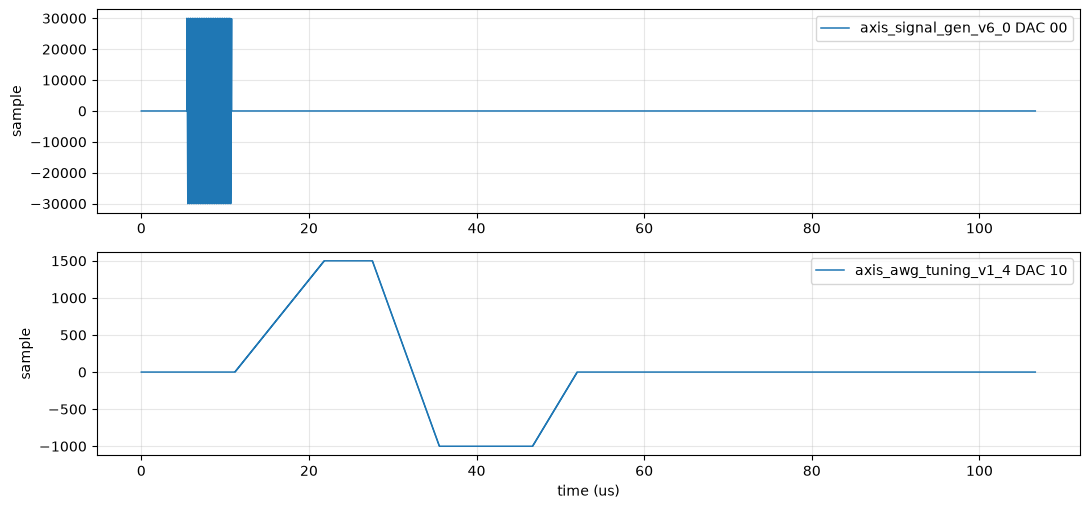

In [ ]:
fig, axes = result.plot_outputs(
    samples=PLOT_SAMPLES,
    channels=active_output_names,
    show=False,
)


## Optional CSV export

In [11]:
SAVE_CSV = False
CSV_PREFIX = REPO / "qick" / "qick_demos" / "qicksim_output_waveform_demo"

if SAVE_CSV:
    csv_paths = result.to_csv(CSV_PREFIX, overwrite=True)
    print(csv_paths)
else:
    print("CSV export disabled. Set SAVE_CSV=True to write files.")

CSV export disabled. Set SAVE_CSV=True to write files.
